In [61]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pandas_datareader as data

In [2]:
import requests
print(requests.get("https://www.google.com").status_code)


200


In [26]:
pip install yfinance


Note: you may need to restart the kernel to use updated packages.


In [6]:

import yfinance as yf

df = yf.download("AAPL",
                 start="2010-01-01",
                 end="2019-12-31")

print(df.head())

[*********************100%***********************]  1 of 1 completed

Price          Close      High       Low      Open     Volume
Ticker          AAPL      AAPL      AAPL      AAPL       AAPL
Date                                                         
2010-01-04  6.406480  6.421148  6.357685  6.389117  493729600
2010-01-05  6.417557  6.453779  6.383729  6.424143  601904800
2010-01-06  6.315475  6.443000  6.308890  6.417555  552160000
2010-01-07  6.303802  6.346310  6.258000  6.338826  477131200
2010-01-08  6.345712  6.346311  6.258302  6.295421  447610800


In [8]:
df.tail()

Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2019-12-23,68.396271,68.456479,67.522050,67.560584,98572000
2019-12-24,68.461288,68.610610,68.136171,68.562441,48478800
2019-12-26,69.819603,69.836463,68.564870,68.593769,93121200
2019-12-27,69.793098,70.797371,69.388503,70.110998,146266000
2019-12-30,70.207329,70.489105,68.690090,69.711216,144114400


In [9]:
df.head()

Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2010-01-04,6.406480,6.421148,6.357685,6.389117,493729600
2010-01-05,6.417557,6.453779,6.383729,6.424143,601904800
2010-01-06,6.315475,6.443000,6.308890,6.417555,552160000
2010-01-07,6.303802,6.346310,6.258000,6.338826,477131200
2010-01-08,6.345712,6.346311,6.258302,6.295421,447610800


In [10]:
df=df.reset_index()
df.head()

Price,Date,Close,High,Low,Open,Volume
Ticker,,AAPL,AAPL,AAPL,AAPL,AAPL
0,2010-01-04,6.406480,6.421148,6.357685,6.389117,493729600
1,2010-01-05,6.417557,6.453779,6.383729,6.424143,601904800
2,2010-01-06,6.315475,6.443000,6.308890,6.417555,552160000
3,2010-01-07,6.303802,6.346310,6.258000,6.338826,477131200
4,2010-01-08,6.345712,6.346311,6.258302,6.295421,447610800


In [11]:
df=df.drop('Date',axis=1)
df.head()

C:\Users\Hi\AppData\Local\Temp\ipykernel_5988\3174241797.py:1: PerformanceWarning: dropping on a non-lexsorted multi-index without a level parameter may impact performance.
  df=df.drop('Date',axis=1)


Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
0,6.406480,6.421148,6.357685,6.389117,493729600
1,6.417557,6.453779,6.383729,6.424143,601904800
2,6.315475,6.443000,6.308890,6.417555,552160000
3,6.303802,6.346310,6.258000,6.338826,477131200
4,6.345712,6.346311,6.258302,6.295421,447610800


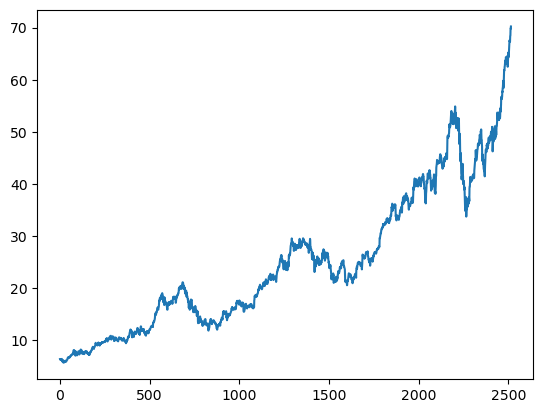

In [12]:
plt.plot(df.Close)

In [13]:
df

Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
0,6.406480,6.421148,6.357685,6.389117,493729600
1,6.417557,6.453779,6.383729,6.424143,601904800
2,6.315475,6.443000,6.308890,6.417555,552160000
3,6.303802,6.346310,6.258000,6.338826,477131200
4,6.345712,6.346311,6.258302,6.295421,447610800
...,...,...,...,...,...
2510,68.396271,68.456479,67.522050,67.560584,98572000
2511,68.461288,68.610610,68.136171,68.562441,48478800
2512,69.819603,69.836463,68.564870,68.593769,93121200


In [14]:
ma100=df.Close.rolling(100).mean()

In [15]:
ma100

Ticker,AAPL
0,NaN
1,NaN
2,NaN
3,NaN
4,NaN
...,...
2510,56.912129
2511,57.108722
2512,57.344444
2513,57.571147


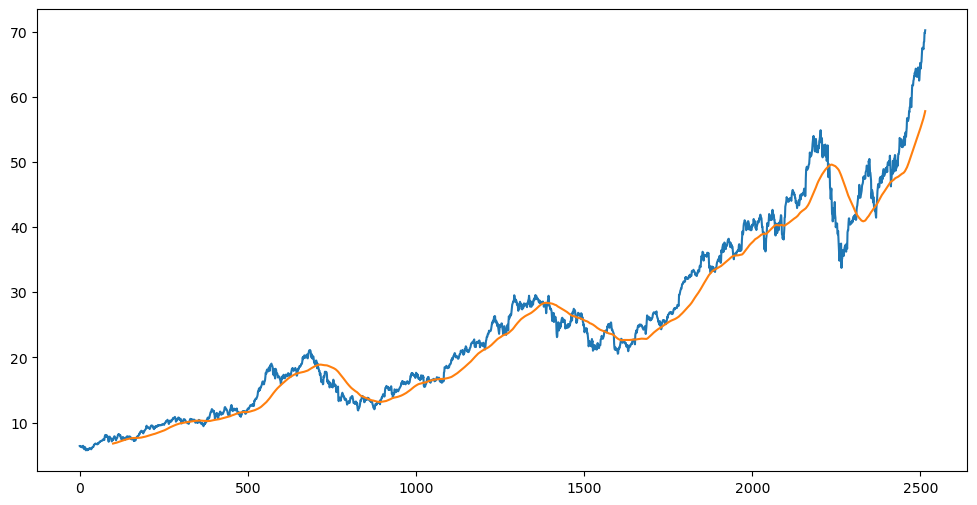

In [16]:
plt.figure(figsize=(12,6))
plt.plot(df.Close)
plt.plot(ma100)

In [17]:
ma200 = df.Close.rolling(200).mean()
ma200

Ticker,AAPL
0,NaN
1,NaN
2,NaN
3,NaN
4,NaN
...,...
2510,51.890289
2511,52.017055
2512,52.149660
2513,52.279725


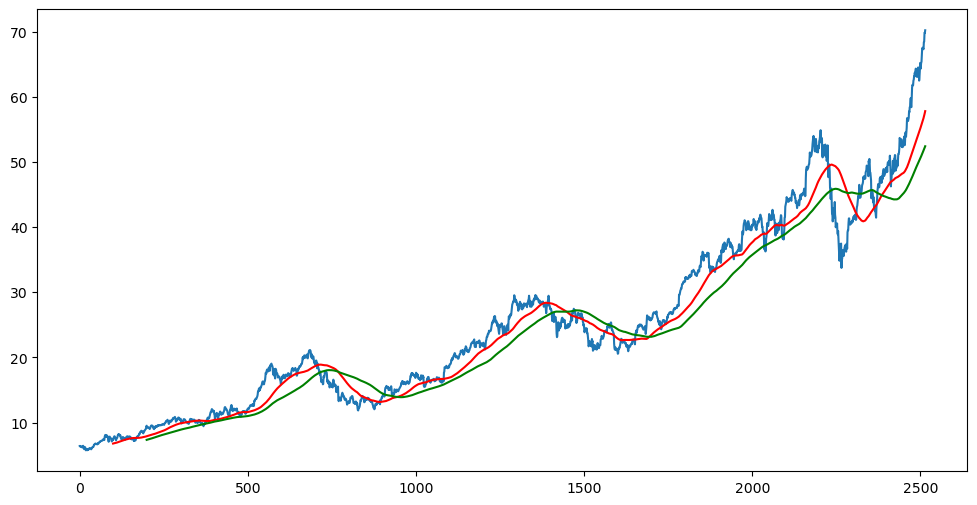

In [18]:
plt.figure(figsize=(12,6))
plt.plot(df.Close)
plt.plot(ma100,'r')
plt.plot(ma200,'g')

In [19]:
df.shape

(2515, 5)

In [20]:
#Splitting Data into Training and Testing
data_training=pd.DataFrame(df['Close'][0:int(len(df)*0.70)])
data_testing=pd.DataFrame(df['Close'][int(len(df)*0.70):int(len(df))])
print(data_training.shape)
print(data_testing.shape)

(1760, 1)
(755, 1)


In [21]:
data_training.head()

Ticker,AAPL
0,6.406480
1,6.417557
2,6.315475
3,6.303802
4,6.345712


In [22]:
data_testing.head()

Ticker,AAPL
1760,26.854673
1761,26.645317
1762,26.721243
1763,26.691332
1764,26.827061


In [23]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler(feature_range=(0,1))

In [24]:
data_training_array = scaler.fit_transform(data_training)
data_training_array

array([[0.02759988],
       [0.02806495],
       [0.02377909],
       ...,
       [0.88408386],
       [0.89123136],
       [0.88640216]], shape=(1760, 1))

In [25]:
x_train=[]
y_train=[]

for i in range(100,data_training_array.shape[0]):
    x_train.append(data_training_array[i-100:i])
    y_train.append(data_training_array[i,0])

x_train,y_train=np.array(x_train), np.array(y_train)

In [26]:
data_training_array.shape

(1760, 1)

pip install keras

Note: you may need to restart the kernel to use updated packages.


ML MODEL

In [48]:
from keras.layers import Dense, Dropout, LSTM, Input
from keras.models import Sequential

In [50]:
model = Sequential()
model.add(Input(shape=(x_train.shape[1],1)))
model.add(LSTM(units= 50,activation='relu',return_sequences=True))
model.add(Dropout(0.2))
model.add(LSTM(units= 60,activation='relu',return_sequences=True))
model.add(Dropout(0.3))
model.add(LSTM(units= 70,activation='relu',return_sequences=True))
model.add(Dropout(0.4))
model.add(LSTM(units= 120,activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(units=1))

In [53]:
model.summary()

Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_32 (LSTM)                  │ (None, 100, 50)        │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_28 (Dropout)            │ (None, 100, 50)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_33 (LSTM)                  │ (None, 100, 60)        │        26,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_29 (Dropout)            │ (None, 100, 60)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_34 (LSTM)                  │ (None, 100, 70)        │        36,680 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_30 (Dropout)            │ (None, 100, 70)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_35 (LSTM)                  │ (None, 120)            │        91,680 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_31 (Dropout)            │ (None, 120)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │           121 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 165,521 (646.57 KB)

 Trainable params: 165,521 (646.57 KB)

 Non-trainable params: 0 (0.00 B)

In [54]:
model.compile(optimizer='adam',loss='mean_squared_error')
model.fit(x_train,y_train,epochs=50)

Epoch 1/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 17s 167ms/step - loss: 0.0606
Epoch 2/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 8s 152ms/step - loss: 0.0126
Epoch 3/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 8s 145ms/step - loss: 0.0106
Epoch 4/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 9s 165ms/step - loss: 0.0099
Epoch 5/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 10s 190ms/step - loss: 0.0099
Epoch 6/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 10s 192ms/step - loss: 0.0085
Epoch 7/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 10s 193ms/step - loss: 0.0092
Epoch 8/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 10s 194ms/step - loss: 0.0084
Epoch 9/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 10s 190ms/step - loss: 0.0074
Epoch 10/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 10s 196ms/step - loss: 0.0084
Epoch 11/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 11s 203ms/step - loss: 0.0084
Epoch 12/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 11s 203ms/step - loss: 0.0066
Epoch 13/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 19s 172ms/step - loss: 0.0071
Epoch 14/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 9s 172ms/step - loss: 0.0063
Epoch 15/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 11s 209m

In [55]:
model.save('keras_model.h5')

In [56]:
data_testing.head()

Ticker,AAPL
1760,26.854673
1761,26.645317
1762,26.721243
1763,26.691332
1764,26.827061


In [57]:
data_training.tail(100)

Ticker,AAPL
1660,24.804033
1661,24.904745
1662,24.719347
1663,24.703333
1664,24.760551
...,...
1755,26.930586
1756,26.753447
1757,26.806358
1758,26.976599


In [58]:
past_100_days = data_training.tail(100)

In [62]:
import pandas as pd
final_df=pd.concat([past_100_days,data_testing], ignore_index=True)

In [63]:
final_df.head()

Ticker,AAPL
0,24.804033
1,24.904745
2,24.719347
3,24.703333
4,24.760551


In [64]:
input_data = scaler.fit_transform(final_df)
input_data

array([[0.02573559],
       [0.02789667],
       [0.02391839],
       [0.02357476],
       [0.02480256],
       [0.03118727],
       [0.03069618],
       [0.02991036],
       [0.02922261],
       [0.03059783],
       [0.02642334],
       [0.02809312],
       [0.02406577],
       [0.02180663],
       [0.01871228],
       [0.01812308],
       [0.01409569],
       [0.01458699],
       [0.01768094],
       [0.02259249],
       [0.02244515],
       [0.02568656],
       [0.01173829],
       [0.        ],
       [0.0113455 ],
       [0.02367291],
       [0.04243434],
       [0.06109759],
       [0.05790521],
       [0.05132392],
       [0.05127481],
       [0.05117658],
       [0.05643185],
       [0.04705101],
       [0.0478859 ],
       [0.04891736],
       [0.05314096],
       [0.04444795],
       [0.04872083],
       [0.04611789],
       [0.04847526],
       [0.04872083],
       [0.05284636],
       [0.05368133],
       [0.06345504],
       [0.06468279],
       [0.06979072],
       [0.068

In [65]:
input_data.shape

(855, 1)

In [66]:
x_test = []
y_test = []
for i in range(100,input_data.shape[0]):
    x_test.append(input_data[i-100:i])
    y_test.append(input_data[i,0])

In [67]:
x_test,y_test = np.array(x_test),np.array(y_test)
print(x_test.shape)
print(y_test.shape)

(755, 100, 1)
(755,)


In [70]:
y_predicted=model.predict(x_test)

24/24 ━━━━━━━━━━━━━━━━━━━━ 3s 103ms/step


In [71]:
y_test

array([0.06973825, 0.06524588, 0.0668751 , 0.06623326, 0.06914574,
       0.07556331, 0.08089507, 0.0814873 , 0.08464657, 0.08217825,
       0.08114171, 0.08588083, 0.08583151, 0.08479485, 0.08588083,
       0.08627554, 0.08573271, 0.09516156, 0.0954578 , 0.09550716,
       0.09392742, 0.09254537, 0.12907606, 0.12798992, 0.13070499,
       0.13667842, 0.1427996 , 0.1453174 , 0.15002755, 0.14854006,
       0.15434082, 0.16291816, 0.16534752, 0.16455438, 0.16638885,
       0.17124769, 0.17328033, 0.17040478, 0.17104915, 0.1723879 ,
       0.1726852 , 0.18656782, 0.18245268, 0.18651822, 0.18433668,
       0.18522923, 0.18265127, 0.18106425, 0.18334516, 0.18364254,
       0.18260142, 0.18988994, 0.19103011, 0.18755934, 0.19484762,
       0.18681576, 0.19464953, 0.19217028, 0.19078225, 0.19197211,
       0.20644945, 0.20803565, 0.20709382, 0.20575523, 0.20595332,
       0.21125873, 0.20754043, 0.20575523, 0.20416862, 0.20332592,
       0.19569041, 0.19653336, 0.19281506, 0.19668184, 0.19355

In [72]:
y_predicted

array([[0.09798685],
       [0.0987719 ],
       [0.09947826],
       [0.10008593],
       [0.10057968],
       [0.10095   ],
       [0.10120402],
       [0.10137013],
       [0.10148869],
       [0.10159878],
       [0.1017358 ],
       [0.1019191 ],
       [0.1021584 ],
       [0.10246372],
       [0.10283536],
       [0.10326488],
       [0.1037403 ],
       [0.1042459 ],
       [0.10477221],
       [0.10532731],
       [0.10591725],
       [0.10654131],
       [0.10718805],
       [0.10788783],
       [0.10873477],
       [0.10981512],
       [0.11120613],
       [0.11297527],
       [0.11517182],
       [0.11782309],
       [0.12092429],
       [0.12444636],
       [0.12835664],
       [0.13260636],
       [0.13711789],
       [0.14178179],
       [0.1464756 ],
       [0.1511253 ],
       [0.15565217],
       [0.15998045],
       [0.16404559],
       [0.16779682],
       [0.17123035],
       [0.17434567],
       [0.17716457],
       [0.17970978],
       [0.18200213],
       [0.184

In [73]:
scaler.scale_

array([0.02145801])

In [74]:
scale_factor=1/0.02145801
y_predicted=y_predicted*scale_factor
y_test=y_test*scale_factor

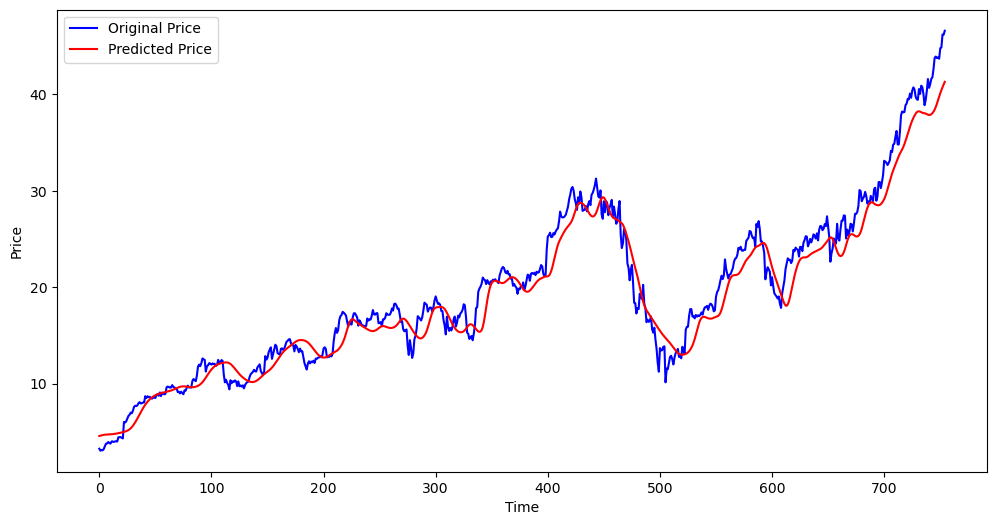

In [75]:
plt.figure(figsize=(12,6))
plt.plot(y_test,'b',label='Original Price')
plt.plot(y_predicted,'r',label='Predicted Price')
plt.xlabel('Time')
plt.ylabel('Price')
plt.legend()
plt.show()